
Initial missing values in full dataset:
timestamp            0
game_id              0
difficulty_label     0
completion_time      0
mistakes             0
hints_used           0
moves                2
provided_numbers     0
n_clusters           0
spread_factor        0
max_mistakes        20
result               1
dtype: int64

Rows with missing values:
           timestamp  game_id difficulty_label  completion_time  mistakes  \
0    4/19/2025 15:49        1         Beginner             1122         1   
1    4/19/2025 16:01        2         Beginner              693         1   
2    4/19/2025 16:15        3         Beginner              873         1   
3    4/19/2025 16:27        4         Beginner              698         3   
4    4/19/2025 16:37        5         Beginner              597         2   
5    4/19/2025 17:01        6     Intermediate             1484         0   
6    4/19/2025 17:32        7     Intermediate             1810         6   
7    4/19/2025 17:50       

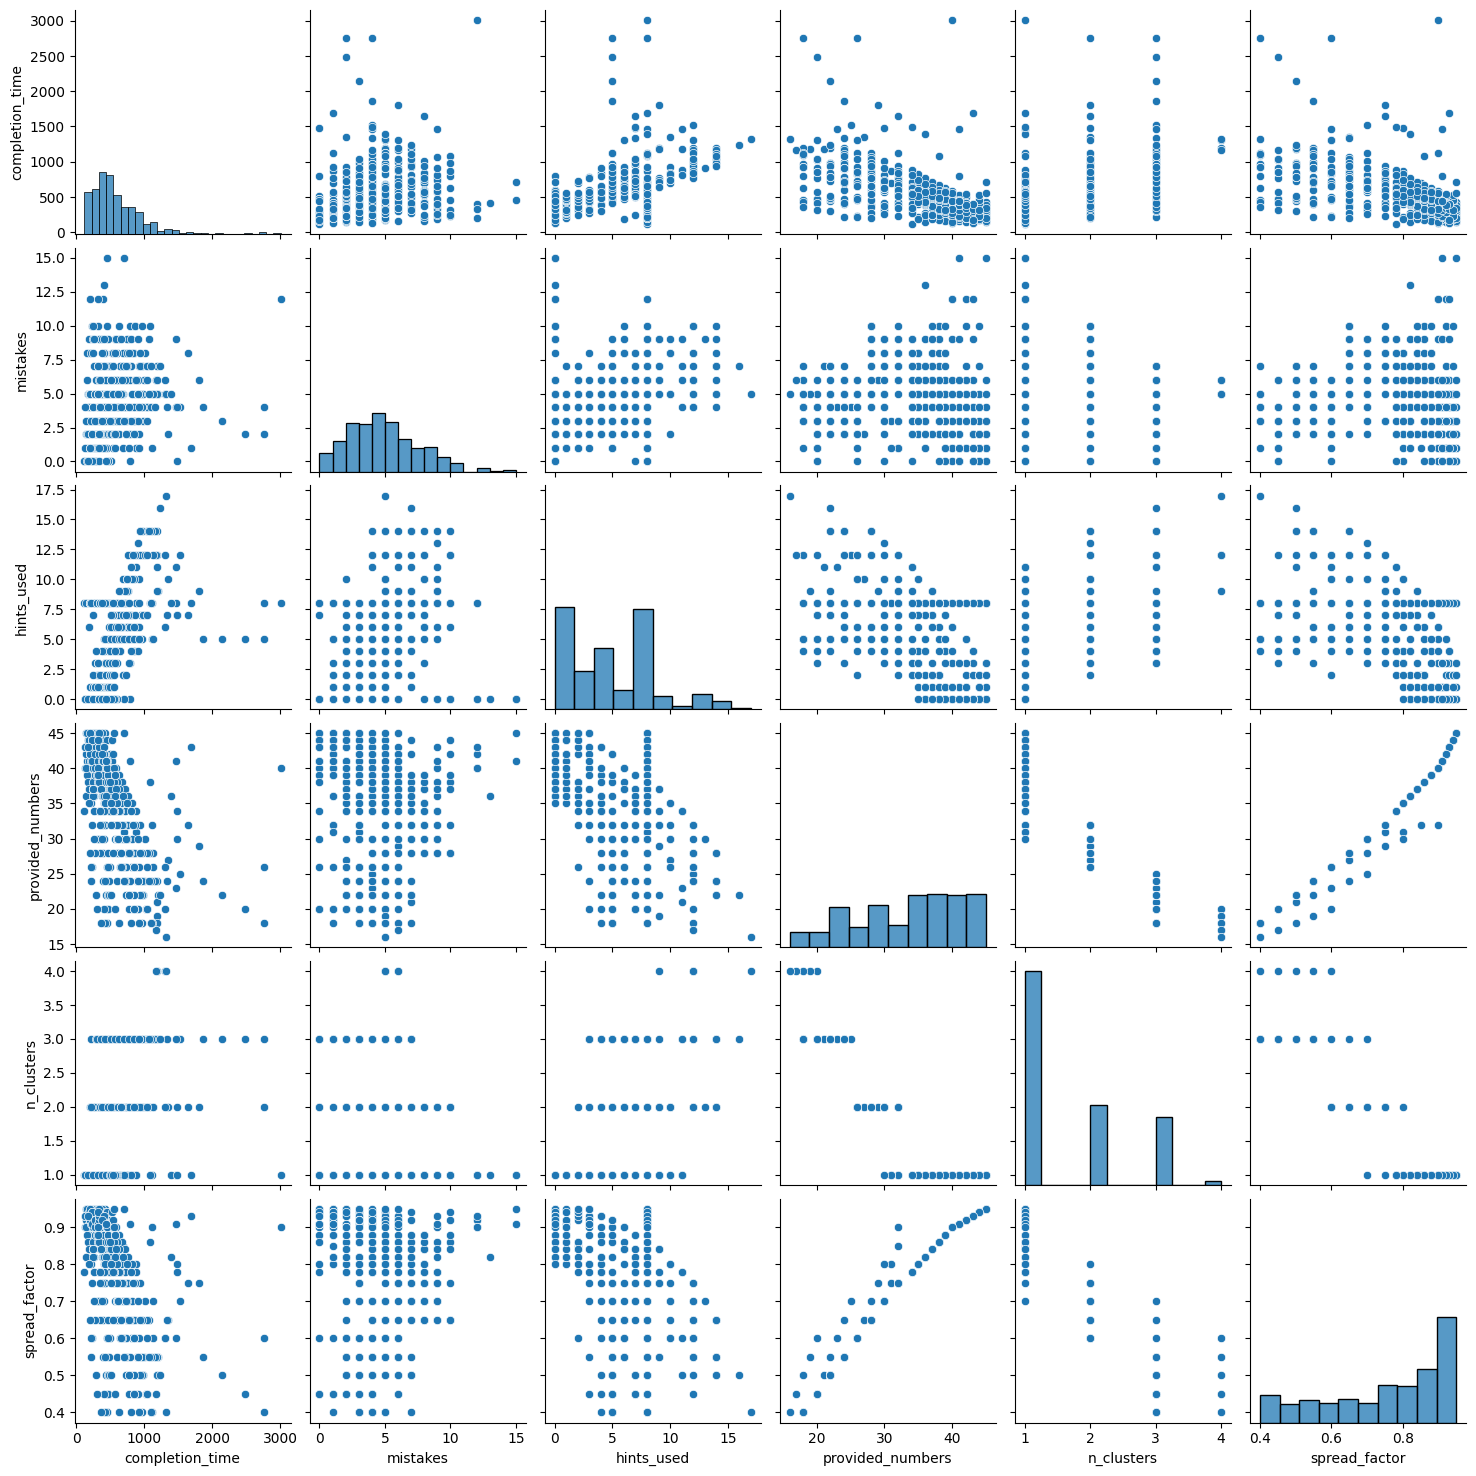

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np  # Add this line with your other imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your complete dataset
df = pd.read_csv('/Users/stalinjosephbaguio/Desktop/merge/model /data/combineddata.csv') 
# After loading data but before processing
print("\nInitial missing values in full dataset:")
print(df.isnull().sum())

# Check which rows have missing values
print("\nRows with missing values:")
print(df[df.isnull().any(axis=1)])
# Show basic stats
print(df.describe())

# Visualize relationships
sns.pairplot(df[['completion_time', 'mistakes', 'hints_used', 
                'provided_numbers', 'n_clusters', 'spread_factor']])
plt.show()

In [14]:
# Create difficulty score (target variable)
df['difficulty_score'] = 45 - df['provided_numbers']

# Normalize features
df['norm_time'] = (df['completion_time'] - df['completion_time'].mean()) / df['completion_time'].std()
df['norm_mistakes'] = df['mistakes'] / df['max_mistakes']

# === NEW FEATURES ===
# Interaction terms
df['time_per_move'] = df['completion_time'] / (df['moves'] + 1e-6)  # Avoid division by zero
df['mistake_rate'] = df['mistakes'] / (df['completion_time'] + 1e-6)

# Difficulty-adjusted metrics
df['hint_efficiency'] = df['hints_used'] / (45 - df['provided_numbers'] + 1e-6)

# Log-transform skewed features
df['log_time'] = np.log1p(df['completion_time'])  # Now works because np is imported

In [15]:
from sklearn.model_selection import train_test_split

# Use only the most predictable targets
X = df[['norm_time', 'norm_mistakes', 'hints_used', 'moves', 'time_per_move', 'mistake_rate']]
y = df[['provided_numbers', 'spread_factor']]  # Removed n_clusters

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
from sklearn.impute import SimpleImputer

# After train_test_split in Block 3
imputer = SimpleImputer(strategy='median')
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

# Better model for non-linear relationships
model = MultiOutputRegressor(
    RandomForestRegressor(
        n_estimators=200,
        max_depth=5,
        random_state=42
    )
)
model.fit(X_train, y_train)
# After model.fit() in Block 4
y_pred = model.predict(X_test)  # This must come BEFORE feature importance analysis

In [17]:
# Feature Importance Analysis
print("\nFeature Importances:")
for i, target in enumerate(['provided_numbers', 'spread_factor']):
    print(f"\nTarget: {target}")
    importances = model.estimators_[i].feature_importances_
    for feature, importance in zip(X_train.columns, importances):
        print(f"{feature}: {importance:.3f}")

# Worst Predictions Analysis
errors = y_test.copy()
errors['pred_provided'] = y_pred[:, 0]
errors['pred_spread'] = y_pred[:, 1]
errors['error_provided'] = abs(errors['provided_numbers'] - errors['pred_provided'])
errors['error_spread'] = abs(errors['spread_factor'] - errors['pred_spread'])

print("\nTop 3 Worst Predictions:")
print(errors.nlargest(3, 'error_provided')[['provided_numbers', 'pred_provided', 'error_provided']])


Feature Importances:

Target: provided_numbers
norm_time: 0.118
norm_mistakes: 0.169
hints_used: 0.072
moves: 0.490
time_per_move: 0.034
mistake_rate: 0.118

Target: spread_factor
norm_time: 0.076
norm_mistakes: 0.088
hints_used: 0.061
moves: 0.609
time_per_move: 0.041
mistake_rate: 0.126

Top 3 Worst Predictions:
     provided_numbers  pred_provided  error_provided
271                36      26.936403        9.063597
19                 16      23.682473        7.682473
371                36      28.623365        7.376635


In [18]:
import joblib

# Save all necessary components
joblib.dump({
    'model': model,
    'features': X_train.columns.tolist(),
    'imputer': imputer,
    'target_names': ['provided_numbers', 'spread_factor']  # Optional but helpful
}, 'sudoku_model_v2.pkl')

print("Model saved successfully with imputer!")

Model saved successfully with imputer!


In [ ]:
# Calculate R² score (updated for 2 targets)
from sklearn.metrics import r2_score
print("\nR² Scores:")
print("Provided Numbers:", r2_score(y_test['provided_numbers'], y_pred[:, 0]))
print("Spread Factor:", r2_score(y_test['spread_factor'], y_pred[:, 1]))  # Note: now using index 1

# Plot residuals (updated for 2 targets)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)  # Changed from 3 to 2 subplots
plt.scatter(y_pred[:, 0], y_pred[:, 0] - y_test['provided_numbers'], alpha=0.5)
plt.title("Residuals: Provided Numbers")

plt.subplot(1, 2, 2)  # Changed from 3 to 2 subplots
plt.scatter(y_pred[:, 1], y_pred[:, 1] - y_test['spread_factor'], alpha=0.5)
plt.title("Residuals: Spread Factor")
plt.tight_layout()
plt.show()


R² Scores:
Provided Numbers: 0.8294481388529149


KeyError: 'n_clusters'